# Linear Regression on Brainvita (From Scratch)

This notebook uses the custom `rice_ml.supervised_learning.LinearRegression` implementation to predict the number of legal moves available in a Brainvita board state. The goal is not just to fit a line: we will connect the OLS objective to the normal equation, explain what the Brainvita features mean, compare against simple baselines, and diagnose whether the linear approximation is useful for this game-state problem.


## Learning Objectives

1. Derive OLS from the least-squares objective.
2. Build a leakage-safe preprocessing pipeline.
3. Train and evaluate your custom linear regression model.
4. Diagnose fit quality with residual analysis.
5. Interpret coefficients responsibly under correlated features.


## Dataset Story

Brainvita is a peg-solitaire game. Each row in `data/brainvita_dataset.csv` summarizes one board state using engineered features such as peg density, jumpable pegs, cluster structure, local adjacency patterns, board geometry, and reachability. The regression target is `num_legal_moves`, the count of immediately available moves from that state.

This target is useful because it acts as a continuous mobility score: high values usually indicate a flexible state with several options, while low values indicate a constrained or nearly stuck state. A linear model is intentionally simple, so the key question is whether a weighted combination of these board-state features gives a strong enough interpretable baseline before moving to nonlinear models.

We exclude raw board encodings and best/worst move coordinates from the feature matrix. Those fields either are not numeric summaries or leak move-selection information that would blur the interpretation of the model.


## 1. Mathematical Foundation

Linear regression assumes that the target can be approximated by a weighted sum of the input features:

$$
\hat{y} = X\beta + \epsilon
$$

For Brainvita, this means each standardized board feature contributes additively to the predicted legal-move count. OLS chooses the coefficient vector that minimizes squared prediction error:

$$
\min_{\beta} \|y - X\beta\|_2^2
$$

Setting the derivative of this objective to zero gives the normal equation:

$$
\beta^* = (X^T X)^{-1}X^T y
$$

The custom `rice_ml` implementation solves this with the pseudo-inverse (`pinv`) rather than a raw matrix inverse, which is more stable when features are correlated or nearly redundant.


## 2. Assumptions Checklist

The linear model is a baseline, not a claim that Brainvita is truly linear. We will check the assumptions that matter most for interpreting this notebook:

- the relationship between engineered features and legal-move count is approximately linear over the sampled states
- residuals are centered near zero and do not show a strong pattern against predictions
- coefficient interpretation is treated carefully because many board features are correlated
- train/test preprocessing is leakage-safe, with scaling parameters learned only from the training set

The diagnostics later in the notebook are meant to test these assumptions rather than simply report a high score.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root with src/rice_ml and data/brainvita_dataset.csv')

ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'

preferred_features = ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']

from rice_ml.supervised_learning import LinearRegression

Matplotlib is building the font cache; this may take a moment.


In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + ['num_legal_moves']
selected_idx = [header.index(c) for c in selected_cols]
arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)

X_raw = arr[:, :-1]
y_reg = arr[:, -1]
y_bin = (y_reg >= 3.0).astype(int)

feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

print('Rows:', f'{X.shape[0]:,}')
print('Features:', X.shape[1])
print('Positive class rate (num_legal_moves >= 3):', round(float(y_bin.mean()), 4))
print('Feature set:', feature_cols)


Rows: 238,486
Features: 15
Positive class rate (num_legal_moves >= 3): 0.2918
Feature set: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']


In [3]:
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)
split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y_reg[train_idx], y_reg[test_idx]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma_safe = np.where(sigma < 1e-12, 1.0, sigma)

X_train = (X_train_raw - mu) / sigma_safe
X_test = (X_test_raw - mu) / sigma_safe

print('Train samples:', f'{X_train.shape[0]:,}', '| Test samples:', f'{X_test.shape[0]:,}')


Train samples: 190,788 | Test samples: 47,698


## 3. Baselines Before Fitting OLS

Before fitting the full model, we compare against two simple reference points. The mean predictor asks whether the model beats the most naive constant forecast. The single-feature baseline asks how much of the signal is already captured by `jumpable_pegs`, the most direct mobility feature. The full OLS model should improve over both to justify its added complexity.

In [4]:
def reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    return {'r2': r2, 'mse': mse, 'rmse': rmse, 'mae': mae}

baseline_pred = np.full_like(y_test, fill_value=float(y_train.mean()), dtype=float)
base_metrics = reg_metrics(y_test, baseline_pred)

single_feat_idx = feature_cols.index('jumpable_pegs') if 'jumpable_pegs' in feature_cols else 0
xtr = X_train[:, [single_feat_idx]]
xts = X_test[:, [single_feat_idx]]

one_feat_model = LinearRegression(fit_intercept=True)
one_feat_model.fit(xtr, y_train)
one_feat_pred = one_feat_model.predict(xts)
one_feat_metrics = reg_metrics(y_test, one_feat_pred)

print('Baseline (mean predictor):', base_metrics)
print('Single-feature baseline:', one_feat_metrics)


Baseline (mean predictor): {'r2': -4.154113762266931e-05, 'mse': 1.1862900009431123, 'rmse': 1.0891694087437052, 'mae': 0.8302017198374586}
Single-feature baseline: {'r2': 0.8936384781774895, 'mse': 0.12617036856249242, 'rmse': 0.3552046854455786, 'mae': 0.2246537735052213}


## 4. Fit Full OLS Model

In [5]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

print(model)
print('Intercept:', round(float(model.intercept_), 6))
print('Number of coefficients:', model.coef_.shape[0])


LinearRegression(fit_intercept=True)
Intercept: 2.08109
Number of coefficients: 15


In [6]:
def reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    return {'r2': r2, 'mse': mse, 'rmse': rmse, 'mae': mae}

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_metrics = reg_metrics(y_train, y_pred_train)
test_metrics = reg_metrics(y_test, y_pred_test)

rows = [
    ('Train', train_metrics),
    ('Test', test_metrics),
    ('Baseline (mean)', base_metrics),
    ('Single feature', one_feat_metrics),
]

print('Performance summary')
print('-' * 86)
print(f"{'Model':<24} {'R2':>10} {'MSE':>14} {'RMSE':>14} {'MAE':>14}")
print('-' * 86)
for name, m in rows:
    print(f"{name:<24} {m['r2']:>10.4f} {m['mse']:>14.4f} {m['rmse']:>14.4f} {m['mae']:>14.4f}")
print('-' * 86)


Performance summary
--------------------------------------------------------------------------------------
Model                            R2            MSE           RMSE            MAE
--------------------------------------------------------------------------------------
Train                        0.9464         0.0647         0.2544         0.1755
Test                         0.9458         0.0643         0.2537         0.1764
Baseline (mean)             -0.0000         1.1863         1.0892         0.8302
Single feature               0.8936         0.1262         0.3552         0.2247
--------------------------------------------------------------------------------------


## 5. Residual Diagnostics

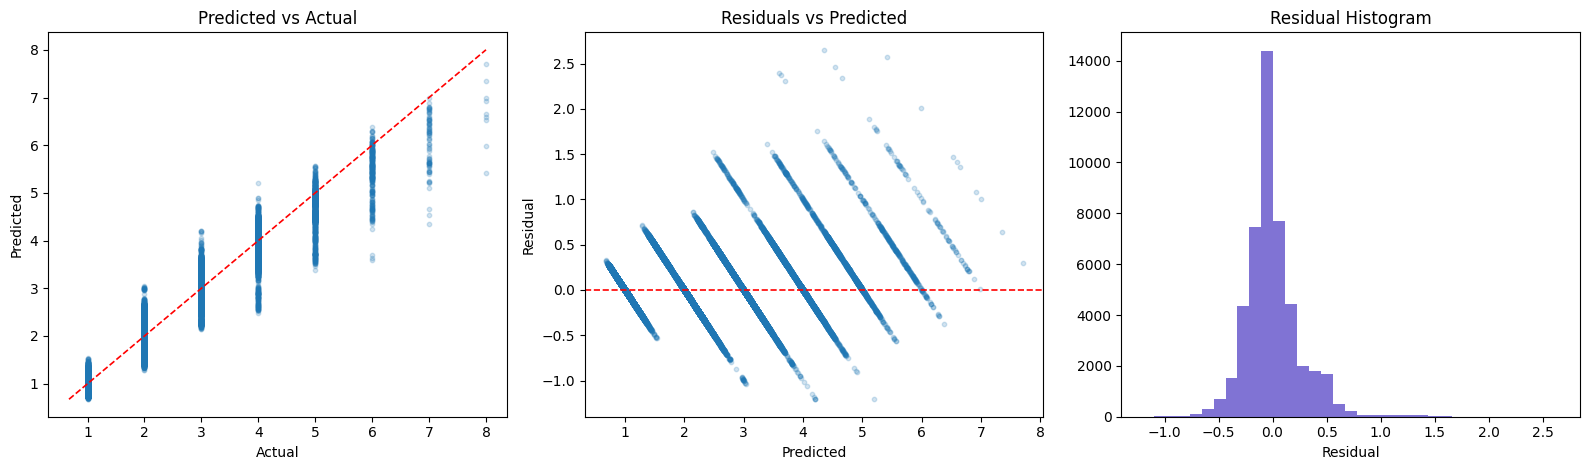

In [7]:
resid = y_test - y_pred_test

fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))

ax[0].scatter(y_test, y_pred_test, alpha=0.2, s=10)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax[0].plot(lims, lims, 'r--', linewidth=1.2)
ax[0].set_title('Predicted vs Actual')
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')

ax[1].scatter(y_pred_test, resid, alpha=0.2, s=10)
ax[1].axhline(0, color='r', linestyle='--', linewidth=1.2)
ax[1].set_title('Residuals vs Predicted')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residual')

ax[2].hist(resid, bins=35, color='slateblue', alpha=0.85)
ax[2].set_title('Residual Histogram')
ax[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()


In [8]:
resid_mean = float(np.mean(resid))
resid_std = float(np.std(resid))
resid_pred_corr = float(np.corrcoef(y_pred_test, resid)[0, 1])

print('Residual summary')
print('-' * 56)
print('Mean residual              :', round(resid_mean, 6))
print('Residual std               :', round(resid_std, 6))
print('Corr(predicted, residual)  :', round(resid_pred_corr, 6))
print('-' * 56)


Residual summary
--------------------------------------------------------
Mean residual              : 0.000514
Residual std               : 0.253659
Corr(predicted, residual)  : -0.006771
--------------------------------------------------------


## 6. Coefficient Interpretation

Top 12 coefficients by |value|
------------------------------------------------------------------------------
Rank  Feature                            Coefficient     |Coefficient|
------------------------------------------------------------------------------
1     jumpable_pegs                         0.766806          0.766806
2     mobility_ratio                        0.344314          0.344314
3     max_adjacent_empty                    0.131831          0.131831
4     avg_adjacent_pegs                     0.097543          0.097543
5     peg_ratio                             0.092926          0.092926
6     max_pegs_reachable                    0.068823          0.068823
7     board_rows                            0.041114          0.041114
8     board_cols                            0.040064          0.040064
9     num_clusters                          0.030312          0.030312
10    avg_adjacent_empty                    0.020833          0.020833
11    largest_cluster         

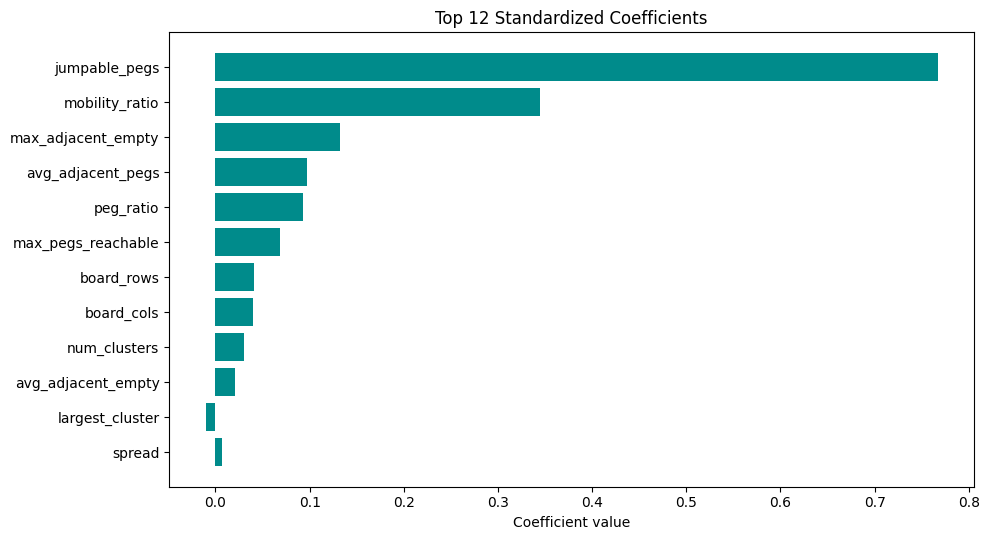

In [9]:
coef = model.coef_
abs_coef = np.abs(coef)
order = np.argsort(abs_coef)[::-1]

print('Top 12 coefficients by |value|')
print('-' * 78)
print(f"{'Rank':<6}{'Feature':<28}{'Coefficient':>18}{'|Coefficient|':>18}")
print('-' * 78)
for rank, i in enumerate(order[:12], start=1):
    print(f"{rank:<6}{feature_cols[i]:<28}{coef[i]:>18.6f}{abs_coef[i]:>18.6f}")
print('-' * 78)

show = order[:12][::-1]
vals = coef[show]
labels = [feature_cols[i] for i in show]
plt.figure(figsize=(10, 5.5))
plt.barh(labels, vals, color='darkcyan')
plt.title('Top 12 Standardized Coefficients')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()


## 7. Sensitivity Demonstration (One Feature Sweep)

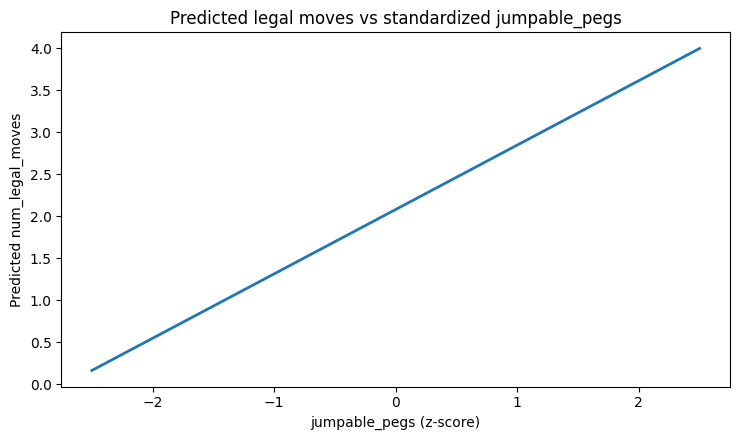

In [10]:
feat = 'jumpable_pegs' if 'jumpable_pegs' in feature_cols else feature_cols[0]
i = feature_cols.index(feat)

z_vals = np.linspace(-2.5, 2.5, 80)
X_proto = np.zeros((len(z_vals), X_train.shape[1]))
X_proto[:, i] = z_vals
pred = model.predict(X_proto)

plt.figure(figsize=(7.5, 4.5))
plt.plot(z_vals, pred, linewidth=2)
plt.title(f'Predicted legal moves vs standardized {feat}')
plt.xlabel(f'{feat} (z-score)')
plt.ylabel('Predicted num_legal_moves')
plt.tight_layout()
plt.show()


## 8. Conclusion

OLS is a strong interpretable baseline for Brainvita mobility. It improves substantially over the mean predictor and the single-feature `jumpable_pegs` baseline, while the train/test metrics stay close enough to suggest the model is not simply memorizing board states.

The coefficient ranking is useful because all features were standardized, but it should not be read causally: peg density, mobility, adjacency, and reachability features are related summaries of the same board. The residual plots and sensitivity sweep show that the linear approximation captures the main trend, while leaving room for nonlinear models such as trees and ensembles to model interactions between local board structure and legal move availability.
